In [1]:
# Dependencies installieren
%pip install matplotlib scikit-image numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 36.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 50.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 77.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 55.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.6/317.6 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 58.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 49.6 MB/s eta 0:00:0000:0

In [89]:
from matplotlib.pyplot import subplots
from skimage import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import math

IMG_REGIONEN_1 = io.imread('regionen1.png', as_gray=True)
IMG_REGIONEN_2 = io.imread('regionen2.png', as_gray=True)

### Vorbereitung: Binarisierung von Bildern

Für die Regionenmarkierung müssen die Bilder in binarisierter Form vorliegen

Wichtig hier, was mich verwirrt hat: **Weiß ist Vordergrund, Schwarz hintergrund**

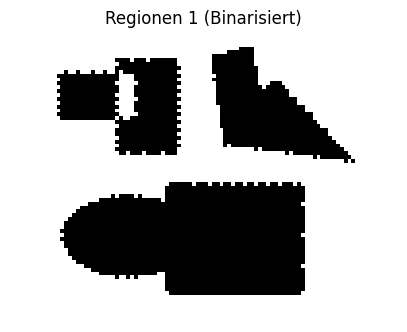

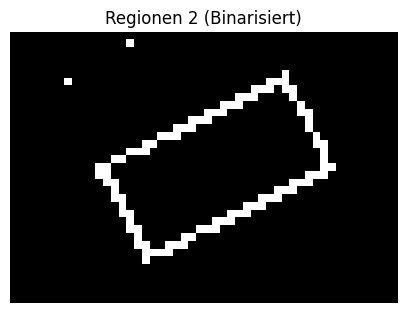

In [72]:
def binarize_image(image, threshold):
    return image.copy() > threshold

THRESH = 0.5

IMG_REGIONEN_1_BIN = binarize_image(IMG_REGIONEN_1, THRESH)
IMG_REGIONEN_2_BIN = binarize_image(IMG_REGIONEN_2, THRESH)

def plot_image(image, title="Bild"):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(image, cmap='gray', interpolation='none')
    ax.set_title(title)
    ax.axis('off')
    plt.show()

plot_image(IMG_REGIONEN_1_BIN, "Regionen 1 (Binarisiert)")
plot_image(IMG_REGIONEN_2_BIN, "Regionen 2 (Binarisiert)")

### Helper Funktionen um Nachbarschaft auszuwerten von einem Pixel

**Wir gehen von oben nach unten von links nach rechts** => Das heißt wir müssen nur die Labels untersuchen von Pixeln die wir bereits untersucht haben 

```
[B][B][B]
[B][*][U]
[U][U][U]

* = Aktuelle Iteration im First Pass
B = Besucht 
N = Nicht besucht
```

In [ ]:
def get_neighbor_labels(r_img, x, y):
    height, width = r_img.shape
    neighbors = []
    
    # Links (x-1, y)
    if x > 0:
        neighbors.append(r_img[y, x-1])
    # Oben-Links (x-1, y-1)
    if x > 0 and y > 0:
        neighbors.append(r_img[y-1, x-1])
    # Oben (x, y-1)
    if y > 0:
        neighbors.append(r_img[y-1, x])
    # Oben-Rechts (x+1, y-1)
    if x < width - 1 and y > 0:
        neighbors.append(r_img[y-1, x+1])
        
    return [n for n in neighbors if n >= 2]

def all_background(r_img, x, y):
    labels = get_neighbor_labels(r_img, x, y)
    return len(labels) == 0

def exactly_one_labeled(r_img, x, y):
    labels = get_neighbor_labels(r_img, x, y)
    unique_labels = list(set(labels))
    if len(unique_labels) == 1:
        return unique_labels[0]
    return None

def several_labeled(r_img, x, y):
    labels = get_neighbor_labels(r_img, x, y)
    unique_labels = list(set(labels))
    if len(unique_labels) > 1:
        return unique_labels
    return None

# Sequentielle Regionenmarkierung

Bei der seq. Regionenmarkierung wird das Verfahren in zwei (bzw. 3 Schritte aufgeteilt)

1. **First Pass**: Im ersten Durchlauf wird für jeden Vordergrundpixel ein Label vergeben (Nachbarschaft beeinflusst auch das Label). Die Bereiche sind 8-Fach-Verbunden d. h. auch Diagonal getrennte Bereiche sind derselbe Bereich (z. B. im ersten Bild ist das der Fall, mit dem Blob der Umgeben ist von Hintergrund). Die Bereiche überschneiden sich aber und müssen zusammegefasst werden, diese Überschneidungen werden in der Kollisionsliste gespeichert

2. **Second Pass**: Im zweiten Durchlauf wird über alle existierenden Labels iteriert und die Labels werden mit der Kollisionsliste zusammengelegt (Alle Labels die kollidieren werden zusammengefasst)

3. **Anwendung der zusammengefassten Labels**: Im letzten Schritt wird die Liste an zusammengefassten Labels verwendet um für einen Pixel zu ermitteln ob es ein kleineres Label gibt mit dem das höhere Label ersetzt werden kann (Weil es denselben Bereich beschreibt)

In [91]:
def seq_region_mark(binary_image, first_pass_only=False):

    height, width = binary_image.shape
    region_image = np.zeros((height, width), dtype=int)
    collisions = set()
    
    # Initielle Markierung mit kollidierenden Labels
    m = first_pass(binary_image, region_image, collisions)

    if first_pass_only:
        return region_image
    
    # Kollidierende Labels zusammenfassen
    R = second_pass(region_image, m, collisions)

    # Für jeden Pixel der im Labelbild ist prüfen wir 
    # ob es ein niedrigeres Label gibt was denselben 
    # Bereich markiert => ggfs. ersetzen
    for y in range(height):
        for x in range(width):

            # Pixel muss nicht angepasst werden wenn er zum Hintergrund gehört
            if binary_image[y][x] == False:
                continue
            
            for s in R:
                if region_image[y][x] in s:
                    region_image[y][x] = min(s)
                    break

    return region_image

def first_pass(b_img, r_img, c):
    
    [height, width] = np.shape(r_img)
    
    # Region Label (unser "Region Iterator")
    m = 2

    for y in range(height):
        for x in range(width):
            # Pixel ohne Inhalt => Überspringen
            if b_img[y][x] == False:
                continue

            if all_background(r_img, x, y):
                r_img[y][x] = m
                m = m + 1
                continue

            exactly_one = exactly_one_labeled(r_img, x, y)

            if(exactly_one != None):
                r_img[y][x] = exactly_one
                continue

            several = several_labeled(r_img, x, y)
            
            if several != None:
                
                k = several[0]
                r_img[y][x] = k
                
                labels = get_neighbor_labels(r_img, x, y)
                unique_labels = set(labels)
                
                for label in unique_labels:
                    if label != k:
                        collision_pair = (min(label, k), max(label, k))
                        c.add(collision_pair)
                        
    return m

def second_pass(r_img, m, c):

    R = [set([i]) for i in range(2, m)]

    for a, b in c:
        set_a = None
        set_b = None

        for s in R:
            if a in s:
                set_a = s
            if b in s:
                set_b = s

        if set_a != set_b and set_a is not None and set_b is not None:
            set_a.update(set_b)
            set_b.clear()

    return R

def plot_labeled_image(r_img, title):
    display_img = r_img.copy().astype(float)
    display_img[display_img == 0] = np.nan
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    current_cmap = mpl.colormaps['tab20'].copy()
    current_cmap.set_bad(color='white')
    
    ax.imshow(display_img, cmap=current_cmap, interpolation='none')
    ax.set_title(title, fontsize=14)
    ax.axis('off')
    plt.show()

# Optische Überprüfung der Resultate

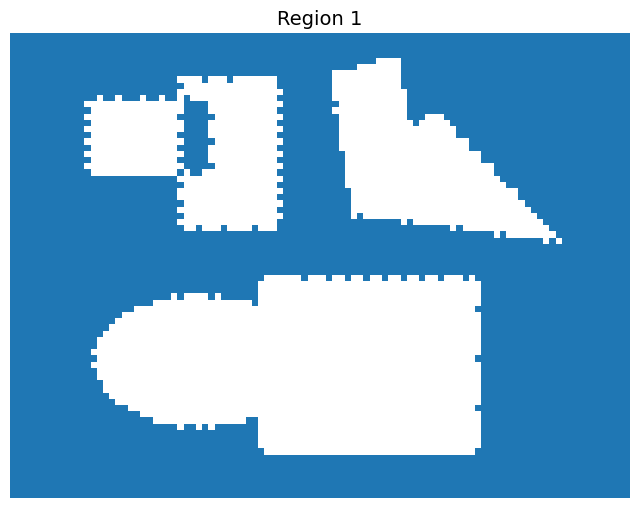

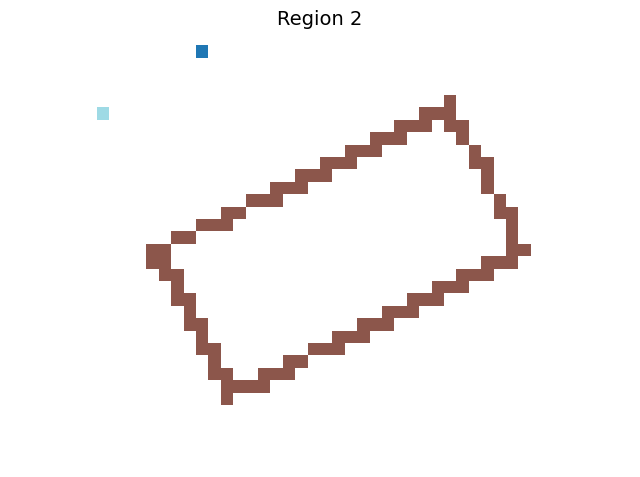

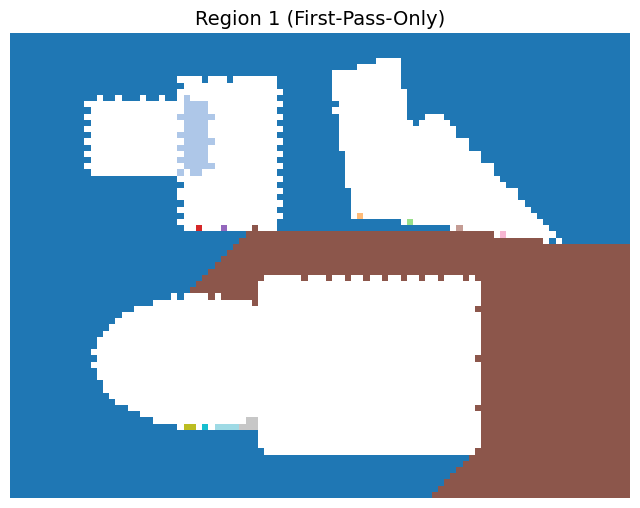

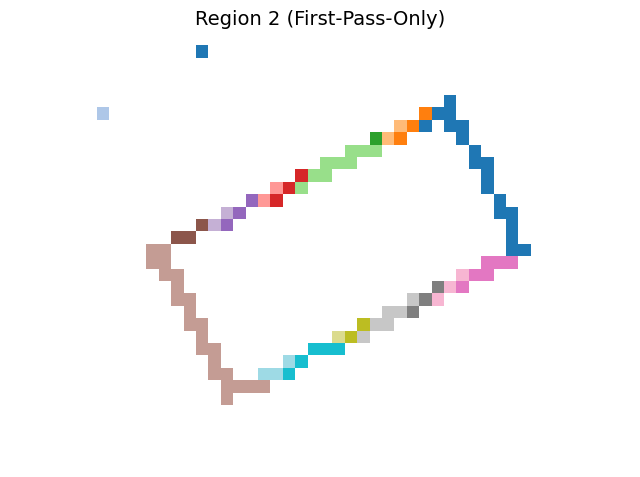

In [96]:
plot_labeled_image(seq_region_mark(IMG_REGIONEN_1_BIN), "Region 1")
plot_labeled_image(seq_region_mark(IMG_REGIONEN_2_BIN), "Region 2")

plot_labeled_image(seq_region_mark(IMG_REGIONEN_1_BIN, True), "Region 1 (First-Pass-Only)")
plot_labeled_image(seq_region_mark(IMG_REGIONEN_2_BIN, True), "Region 2 (First-Pass-Only)")